# Example solution: Linear regression task

In [1]:
# Create a custom Pytorch data set
import numpy as np
import torch
from torch.utils.data import Dataset

class CustomRegressionDataset(Dataset):
    def __init__(self, filename, transform=None, target_transform=None):
        self.dataset = torch.from_numpy(np.loadtxt(filename, delimiter=',')).float()
        self.transform = transform
        self.target_transform = target_transform

    # The __len__ method returns the number of samples in our dataset.
    def __len__(self):
        return len(self.dataset)

    # The __getitem__ method loads and returns a sample from the dataset at the given index idx.
    def __getitem__(self, idx):
        x = self.dataset[idx, :-1]
        y = self.dataset[idx, -1]
        if self.transform:
            x = self.transform(x)
        if self.target_transform:
            y = self.target_transform(y)
        return x, y

In [9]:
from torch.utils.data import DataLoader

training_data = CustomRegressionDataset('../train_data.csv')
test_data = CustomRegressionDataset('../test_data.csv')
print(training_data[0])
batch_size = 128
train_dataloader = DataLoader(training_data, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=batch_size, shuffle=True)

train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
for i in range(5):
    print(train_features[i], train_labels[i])

(tensor([-0.4760, -0.6826, -0.4437, -0.0814, -0.3580,  0.0368, -0.4761,  0.9522,
         0.4656, -0.7695]), tensor(0.0949))
Feature batch shape: torch.Size([128, 10])
Labels batch shape: torch.Size([128])
tensor([ 0.8098, -0.1794,  0.2962,  0.8918, -0.2521,  0.2079,  0.7008, -0.1621,
         0.2363,  0.6127]) tensor(-0.1823)
tensor([ 0.8172,  0.1393, -0.2698, -0.8247, -0.0935,  0.8307,  0.5498, -0.5189,
        -0.6718, -0.6908]) tensor(0.5008)
tensor([-0.3412,  0.0590,  0.9661, -0.5814,  0.1574, -0.3984, -0.7042,  0.6166,
        -0.5258, -0.9096]) tensor(-1.4188)
tensor([ 0.5375, -0.4845, -0.5921, -0.5609,  0.8868,  0.3639, -0.7066,  0.1956,
         0.6500,  0.4776]) tensor(0.9072)
tensor([-0.1299, -0.3583,  0.2485, -0.0167,  0.7809,  0.0210, -0.9692, -0.3702,
        -0.1520, -0.1141]) tensor(-0.5426)


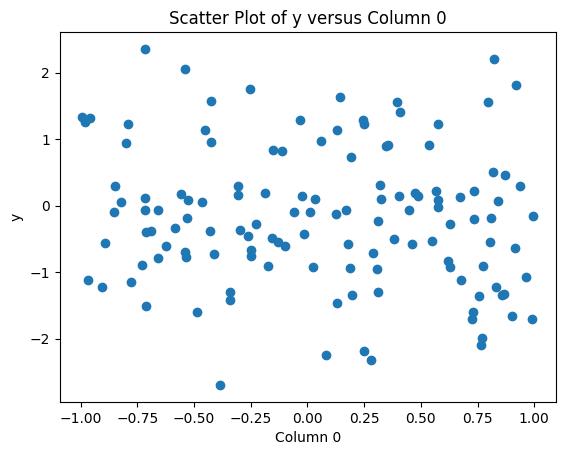

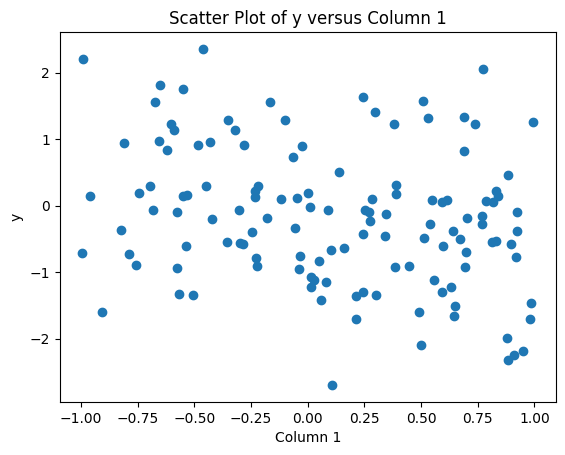

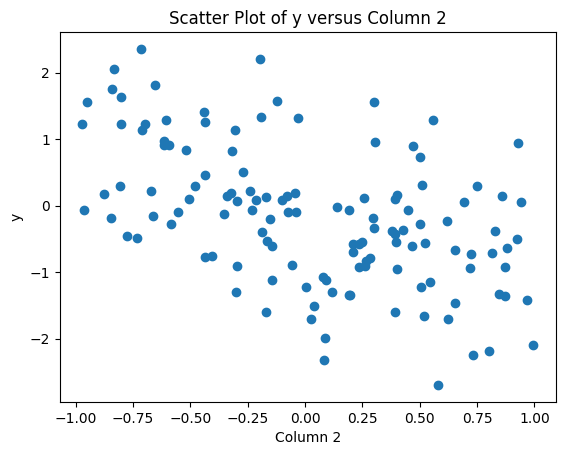

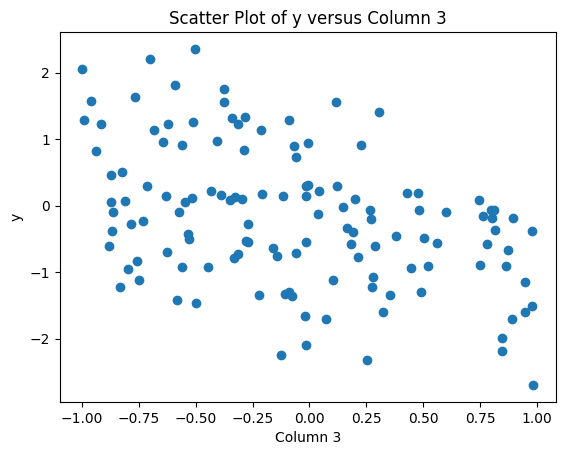

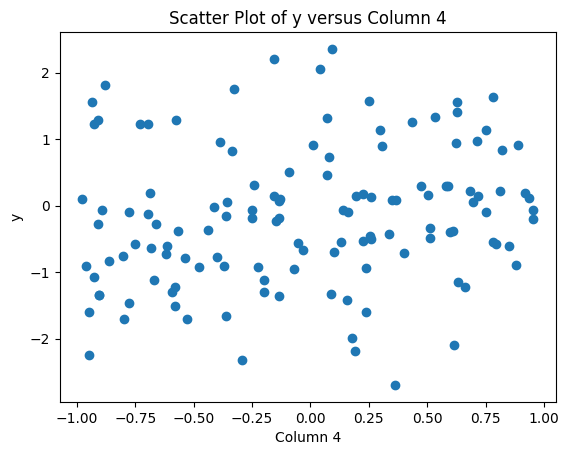

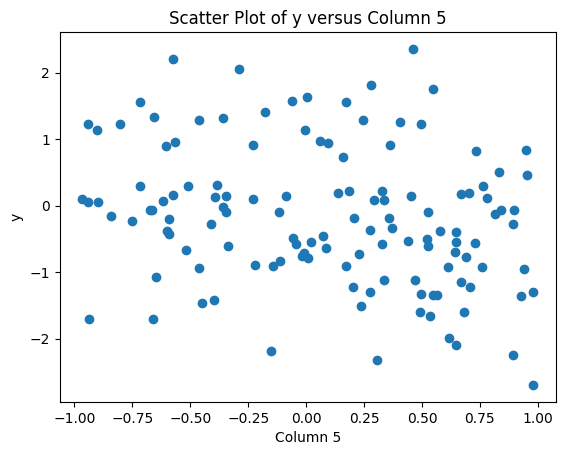

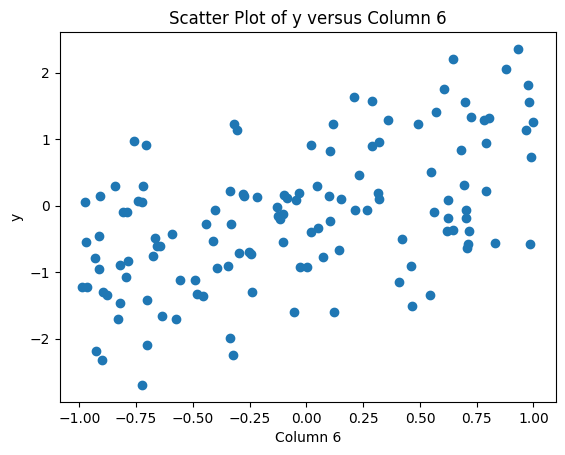

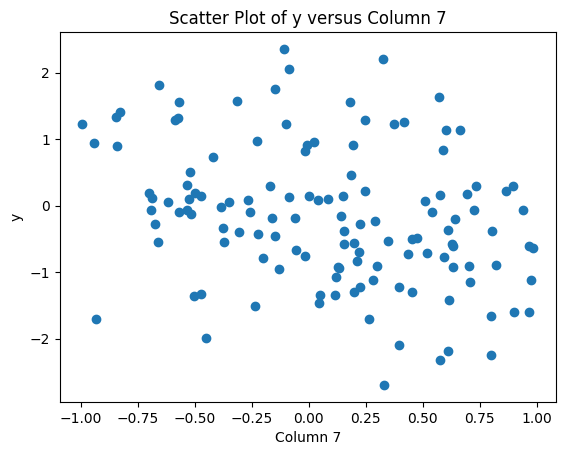

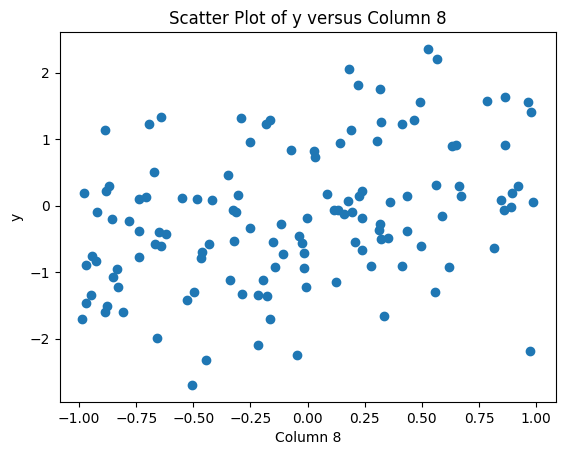

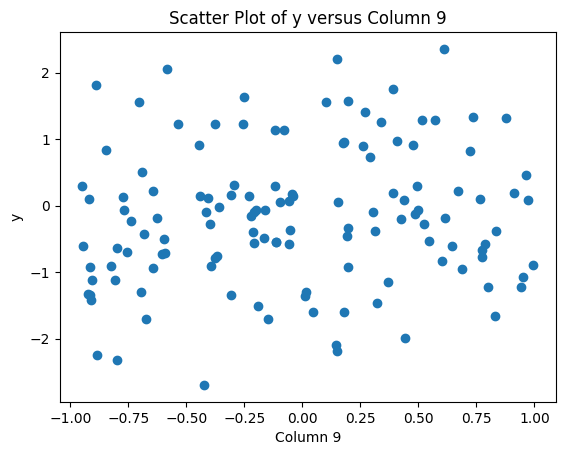

In [10]:
# Make some scatter plots for one batch
import matplotlib.pyplot as plt 

for i in range(train_features.size()[1]):
    plt.scatter(train_features[:, i], train_labels)
    plt.xlabel('Column {}'.format(i))
    plt.ylabel('y')
    plt.title('Scatter Plot of y versus Column {}'.format(i))
    plt.show()

In [12]:
from torch import nn

class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(10, 1, bias=False) # Super shallow network

    def forward(self, x):
        y = self.linear(x)
        return y

model = NeuralNetwork()

In [19]:
learning_rate = 1e-3
epochs = 70

loss_fn = nn.MSELoss()

optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [20]:
# loops over our optimization code
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    # Set the model to training mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        # Compute prediction and loss
        pred = model(X).squeeze()
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), batch * batch_size + len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")


In [21]:
# evaluate the model's performance against the test dataset
def test_loop(dataloader, model, loss_fn):
    # Set the model to evaluation mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, sum_of_residuals = 0, 0

    # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X).squeeze()
            test_loss += loss_fn(pred, y).item()
            residuals = ((pred.squeeze()-y)**2).sum()
            sum_of_residuals += residuals

    test_loss /= num_batches
    sum_of_residuals /= size
    print(f"Test Error: \n sum_of_residuals: {sum_of_residuals:>6f}, Avg loss: {test_loss:>8f} \n")
    return test_loss

In [22]:
# Train
test_loss = []
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_dataloader, model, loss_fn, optimizer)
    test_loss.append(test_loop(test_dataloader, model, loss_fn))
print("Done!")

Epoch 1
-------------------------------
loss: 0.019648  [  128/10000]
Test Error: 
 sum_of_residuals: 0.015344, Avg loss: 0.015300 

Epoch 2
-------------------------------
loss: 0.013696  [  128/10000]
Test Error: 
 sum_of_residuals: 0.014781, Avg loss: 0.014765 

Epoch 3
-------------------------------
loss: 0.015331  [  128/10000]
Test Error: 
 sum_of_residuals: 0.014281, Avg loss: 0.014263 

Epoch 4
-------------------------------
loss: 0.016429  [  128/10000]
Test Error: 
 sum_of_residuals: 0.013828, Avg loss: 0.013829 

Epoch 5
-------------------------------
loss: 0.015976  [  128/10000]
Test Error: 
 sum_of_residuals: 0.013426, Avg loss: 0.013366 

Epoch 6
-------------------------------
loss: 0.012070  [  128/10000]
Test Error: 
 sum_of_residuals: 0.013066, Avg loss: 0.013027 

Epoch 7
-------------------------------
loss: 0.016621  [  128/10000]
Test Error: 
 sum_of_residuals: 0.012749, Avg loss: 0.012799 

Epoch 8
-------------------------------
loss: 0.011942  [  128/10000]

Parameter name: linear.weight, Size: torch.Size([1, 10]), Values: Parameter containing:
tensor([[-0.1297, -0.4725, -0.8370, -0.9102,  0.2144, -0.4439,  0.7612, -0.3804,
          0.4739,  0.2575]], requires_grad=True)


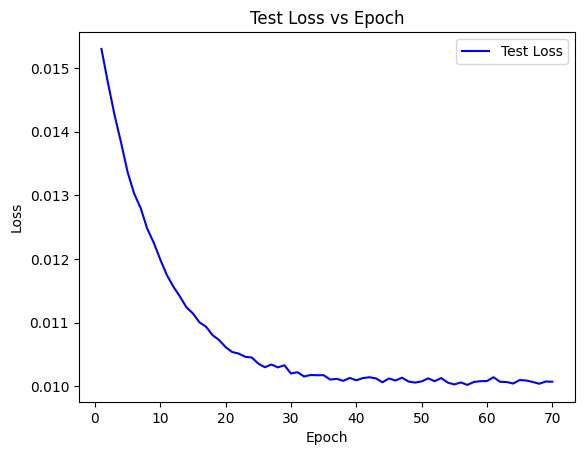

In [23]:
for name, param in model.named_parameters():
    print(f"Parameter name: {name}, Size: {param.size()}, Values: {param}")

import matplotlib.pyplot as plt
# Assuming you have the `test_loss` variable containing the loss values for each epoch
epochs = range(1, len(test_loss) + 1)
plt.plot(epochs, test_loss, 'b', label='Test Loss')
plt.title('Test Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()